# Fit LG — Twitch community graphs (`twitch`)

Batch fit and model comparison for **all networks** in this collection.

Six MUSAE Twitch community graphs (`data/twitch/graphs_processed/*_graph.edges`), sorted by |V|.

**Per network**, the fit loop logs four steps and saves a 4-panel report (`runs/twitch/{graph}/fit_report.png`):

1. **Load** — graph size and structural attributes  
2. **AIC** — pick `d̂` over candidates `[0,1,2,3]`  
3. **σ̂** — Layer-2 offset logit at `d̂`  
4. **Compare** — LG vs ER / WS / BA (`GraphModelComparator`, spectral GIC)

Reports are also displayed inline (only 6 networks). Aggregate outputs: `runs/twitch/`.

## 1. Discover networks

In [ ]:
import os
import sys
import warnings
from pathlib import Path

for v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(v, "1")
warnings.filterwarnings("ignore", category=DeprecationWarning)

_REFACTOR = Path.cwd()
if str(_REFACTOR) not in sys.path:
    sys.path.insert(0, str(_REFACTOR))

from platform_fit_utils import PlatformConfig, discover_graph_files, print_discovery

# ---- Batch settings (edit here) --------------------------------------------
MIN_NODES = 0
MAX_NODES = 10_000      # skip graphs with n > MAX_NODES; set None for no cap
USE_CACHE = True     # reload finished networks from runs/{platform}/{graph}/

cfg = PlatformConfig(
    platform="twitch",
    glob_pattern="twitch/graphs_processed/*_graph.edges",
    min_nodes=MIN_NODES,
    max_nodes=MAX_NODES,
    use_cache=USE_CACHE,
    display_plots=True,
)

graph_files = discover_graph_files(cfg)
print_discovery(cfg, graph_files)

PLATFORM=twitch  RUN_DIR=/Users/maruanottoni/home/master/research/all_logit/logit-graph/notebooks/refactors/runs/twitch
Found 6 networks (MIN_NODES=0, MAX_NODES=10000, USE_CACHE=True)
                PTBR_graph.edges  n= 1912  |E|=  31299  [cached]
                  RU_graph.edges  n= 4385  |E|=  37304
                  ES_graph.edges  n= 4648  |E|=  59382
                  FR_graph.edges  n= 6549  |E|= 112666
                ENGB_graph.edges  n= 7126  |E|=  35324
                  DE_graph.edges  n= 9498  |E|= 153138


: 

## 2. Fit all networks

19:37:33  === twitch batch fit  (6 networks, MAX_NODES=10000, cache=True) ===
19:37:33  [1/6] PTBR_graph  CACHED  (n=1912, best=ER, GIC=3.107)
19:37:33  [2/6] RU_graph
19:40:04    STEP 1/4  Load graph  n=4385 |E|=37304 density=0.0039 clustering=0.166 assort=-0.182
19:53:06    STEP 2/4  AIC select d  d̂=1  (d=0:AIC=488663.2  d=1:AIC=427223.5  d=2:AIC=448898.6  d=3:AIC=490399.4)  [782.3s]
19:53:08    STEP 3/4  Estimate σ at d̂  σ̂=-6.0470  [1.6s]
19:53:08    STEP 4/4  Model comparison  LG max_iter=20000  baselines=ER/WS/BA

============================== Processing Graph: RU_graph ==============================

--- Fitting Logit Graph (LG) model ---
Running LG generation for d=1 (warm_start_p=0.0200)...


Optimizing Graph:   0%|          | 0/20000 [00:00<?, ?it/s] 


Stopping: max iterations (20,000) reached
  Best iteration: 19,950
  Best spectrum diff: 5291.5793
  Edges in best graph: 192762 (real: 37304)
d=1: GIC=15.8937, sigma=-6.0467
Best LG fit found with GIC: 15.8937

--- Fitting other random graph models ---
Testing the selected model for ER
ER gic: 10.416570062394884
Testing the selected model for WS
WS gic: 5.671277200934456
Testing the selected model for BA
BA gic: 4.351983738311197
BA fitting - GIC: 4.3520, Param: 8.0000
WS fitting - GIC: 5.6713, Param: 80.0100
ER fitting - GIC: 10.4166, Param: 0.0100

--- Calculating graph attributes ---
00:49:27    RESULT  best=BA  GIC=4.352  (BA=4.352  WS=5.671  ER=10.417  LG=15.894)  [compare 17779.1s | total 18714.2s]
00:49:27    Saved fit_report.png


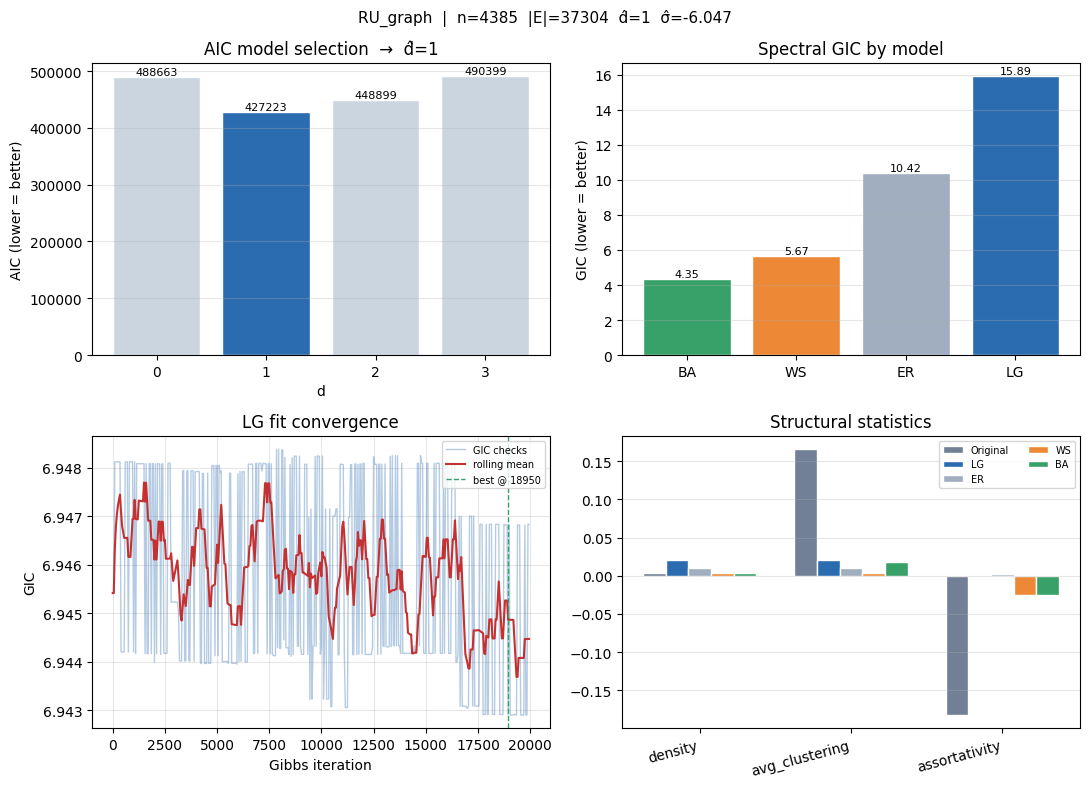

00:49:28  [3/6] ES_graph
00:53:19    STEP 1/4  Load graph  n=4648 |E|=59382 density=0.0055 clustering=0.222 assort=-0.189
01:14:58    STEP 2/4  AIC select d  d̂=1  (d=0:AIC=736400.7  d=1:AIC=615075.2  d=2:AIC=650382.7  d=3:AIC=747943.2)  [1299.4s]
01:15:01    STEP 3/4  Estimate σ at d̂  σ̂=-5.8008  [2.3s]
01:15:01    STEP 4/4  Model comparison  LG max_iter=20000  baselines=ER/WS/BA

============================== Processing Graph: ES_graph ==============================

--- Fitting Logit Graph (LG) model ---
Running LG generation for d=1 (warm_start_p=0.0200)...


Optimizing Graph:   0%|          | 0/20000 [00:00<?, ?it/s] 


Stopping: max iterations (20,000) reached
  Best iteration: 19,950
  Best spectrum diff: 5449.2887
  Edges in best graph: 216753 (real: 59382)
d=1: GIC=12.3551, sigma=-5.8008
Best LG fit found with GIC: 12.3551

--- Fitting other random graph models ---
Testing the selected model for ER
ER gic: 6.857954382395353
Testing the selected model for WS
WS gic: 4.649438106018543
Testing the selected model for BA
BA gic: 3.154982269403371
BA fitting - GIC: 3.1550, Param: 8.0000
WS fitting - GIC: 4.6494, Param: 80.1325
ER fitting - GIC: 6.8580, Param: 0.0100

--- Calculating graph attributes ---
07:15:40    RESULT  best=BA  GIC=3.155  (BA=3.155  WS=4.649  ER=6.858  LG=12.355)  [compare 21638.9s | total 23172.0s]
07:15:40    Saved fit_report.png


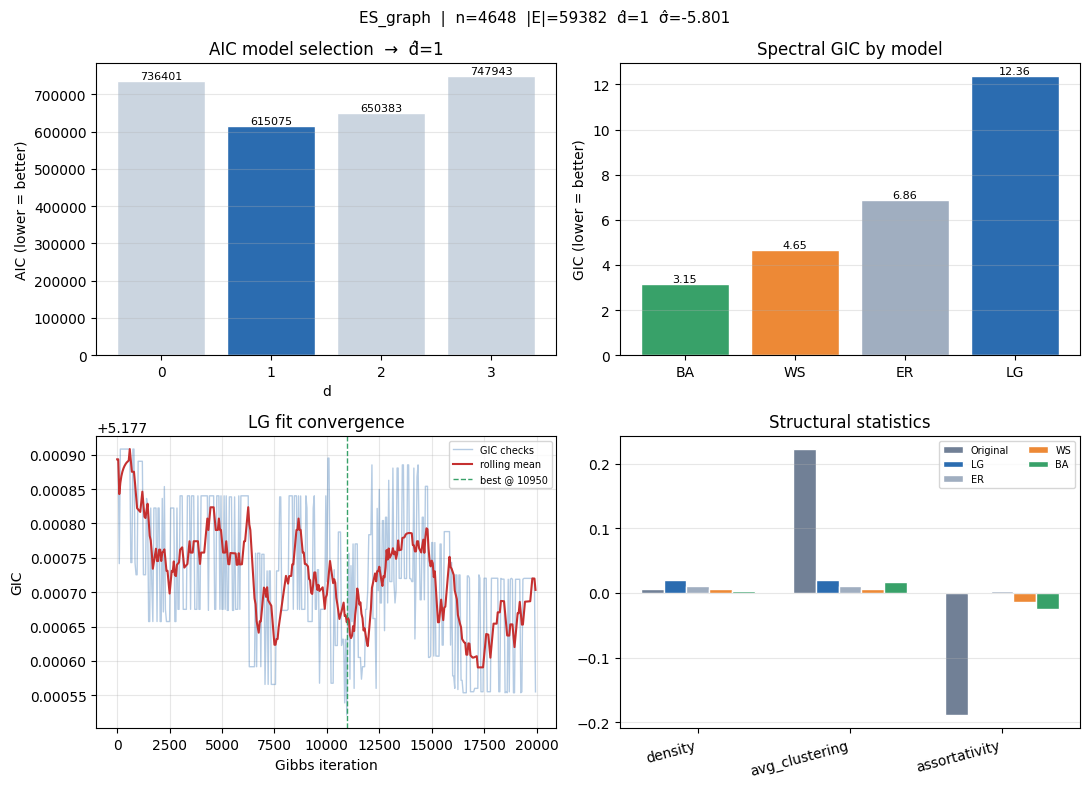

07:15:40  [4/6] FR_graph
07:25:30    STEP 1/4  Load graph  n=6549 |E|=112666 density=0.0053 clustering=0.222 assort=-0.178
08:55:08    STEP 2/4  AIC select d  d̂=1  (d=0:AIC=1407430.3  d=1:AIC=1217215.6  d=2:AIC=1293395.3  d=3:AIC=1469044.0)  [5377.3s]
08:55:14    STEP 3/4  Estimate σ at d̂  σ̂=-6.0846  [6.0s]
08:55:14    STEP 4/4  Model comparison  LG max_iter=20000  baselines=ER/WS/BA

============================== Processing Graph: FR_graph ==============================

--- Fitting Logit Graph (LG) model ---
Running LG generation for d=1 (warm_start_p=0.0200)...


Optimizing Graph:   0%|          | 0/20000 [00:00<?, ?it/s] 

In [ ]:
from platform_fit_utils import fit_all_networks

comparators, summary_all, fit_meta, failures = fit_all_networks(graph_files, cfg)
RUN_DIR = cfg.run_dir

## 3. Aggregate comparison

In [ ]:
from platform_fit_utils import summarize_aggregates

gic_pivot, rank_pivot, mean_rank = summarize_aggregates(summary_all, RUN_DIR)

## 4. Summary plots

In [ ]:
from platform_fit_utils import plot_aggregate_summary

plot_aggregate_summary(fit_meta, mean_rank, RUN_DIR, cfg.platform, display=True)